In [86]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [87]:
df = yf.download("^NSEI", start="2019-06-06",end= '2026-01-01',auto_adjust=False,multi_level_index=False)
df.drop(columns=['Close','High','Low','Open','Volume'], inplace=True)

df['returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))
df['lag1'] = df['returns'].shift(1)
df['ma_5'] = df['returns'].rolling(5).mean()
df["volatility_5"] = df['returns'].rolling(15).std()
df.dropna(inplace=True)
x = df[['lag1','ma_5','volatility_5']]
y = df['returns']

[*********************100%***********************]  1 of 1 completed


In [88]:
from sklearn.linear_model import LinearRegression

window = 22
forecast = []
coef = []
dates = []

for i in range(window,len(df)):

    x_train = x.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    x_test = x.iloc[i:i+1]
    model = LinearRegression().fit(x_train, y_train)
    prediction = model.predict(x_test)

    forecast.append(prediction[0])
    coef.append(model.coef_)
    dates.append(x_test.index[0])

results = pd.DataFrame({'pred':pred},index=dates)
results['actual'] = df.loc[results.index,'returns']
results['residual'] = results['actual'] - results['pred']
results

,pred,actual,residual
2019-07-29,0.003621,-0.008463,-0.012085
2019-07-30,-0.003094,-0.009320,-0.006226
2019-07-31,-0.003999,0.002936,0.006936
2019-08-01,-0.002542,-0.012490,-0.009948
2019-08-02,-0.006043,0.001579,0.007622
...,...,...,...
2025-12-24,0.001941,-0.001340,-0.003281
2025-12-26,0.000537,-0.003825,-0.004362
2025-12-29,0.000097,-0.003855,-0.003952
2025-12-30,0.001506,-0.000125,-0.001631


In [89]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(results['actual'], results['pred'])
mae  = mean_absolute_error(results['actual'], results['pred'])
rmse = np.sqrt(mse)
r2   = r2_score(results['actual'], results['pred'])

print("mse :", mse)
print("mae :", mae)
print("rmse :",rmse)
print("r2 :", r2)

print("Residual Mean",results['residual'].mean())
print("Residual Std",results['residual'].std())
print("Residual Variance",results['residual'].var())
print("Residual AutoCorr",results['residual'].autocorr())


mse : 0.0001498145569364148
mae : 0.007789422234071575
rmse : 0.012239875691215773
r2 : -0.15603408220106663
Residual Mean -0.00039294470598397874
Residual Std 0.01223742028401235
Residual Variance 0.00014975445520755691
Residual AutoCorr 0.12412193823966272


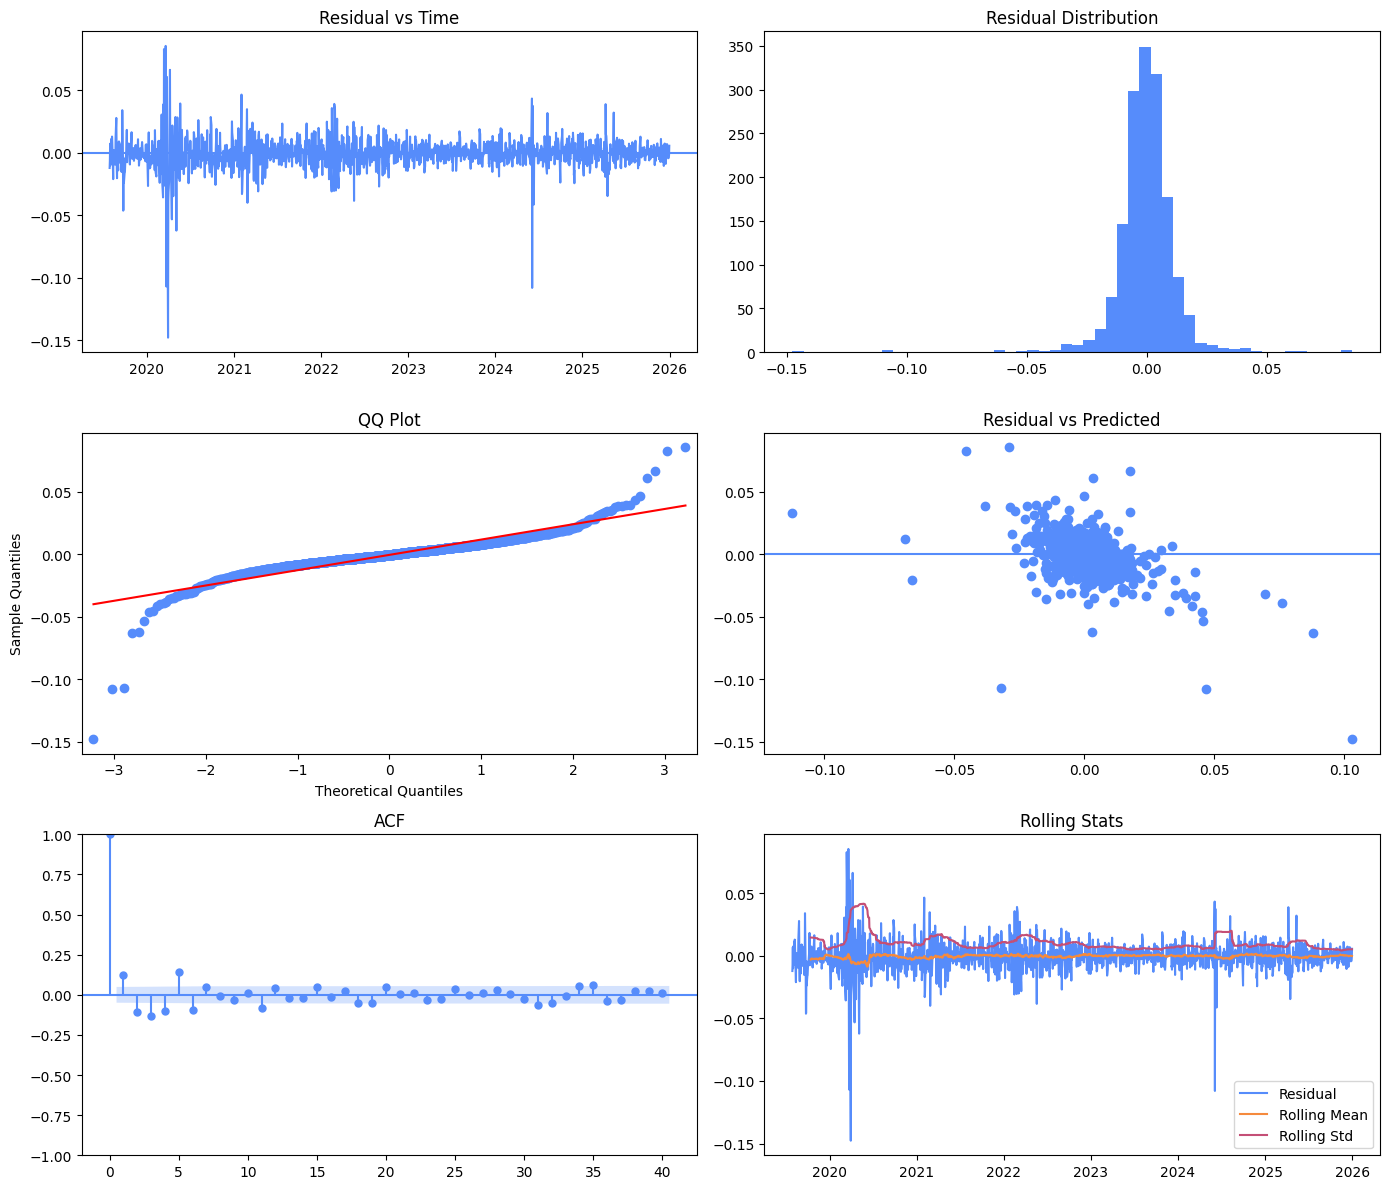

In [90]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# assume: residual is a pandas Series
# residual = df['residual']  (example)
residual = results['residual']
predicted = results['pred']

# assume:
# residual = your residual series
# predicted = your predictions

window = 50
rolling_mean = residual.rolling(window).mean()
rolling_std = residual.rolling(window).std()

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# -----------------------------
# 1. Residual vs Time
# -----------------------------
axes[0, 0].plot(residual)
axes[0, 0].axhline(0)
axes[0, 0].set_title("Residual vs Time")

# -----------------------------
# 2. Histogram
# -----------------------------
axes[0, 1].hist(residual, bins=50)
axes[0, 1].set_title("Residual Distribution")

# -----------------------------
# 3. QQ Plot
# -----------------------------
sm.qqplot(residual, line='s', ax=axes[1, 0])
axes[1, 0].set_title("QQ Plot")

# -----------------------------
# 4. Residual vs Predicted
# -----------------------------
axes[1, 1].scatter(predicted, residual)
axes[1, 1].axhline(0)
axes[1, 1].set_title("Residual vs Predicted")

# -----------------------------
# 5. ACF
# -----------------------------
plot_acf(residual, lags=40, ax=axes[2, 0])
axes[2, 0].set_title("ACF")

# -----------------------------
# 6. Rolling Mean & Std
# -----------------------------
axes[2, 1].plot(residual, label='Residual')
axes[2, 1].plot(rolling_mean, label='Rolling Mean')
axes[2, 1].plot(rolling_std, label='Rolling Std')
axes[2, 1].legend()
axes[2, 1].set_title("Rolling Stats")

plt.tight_layout()
plt.show()

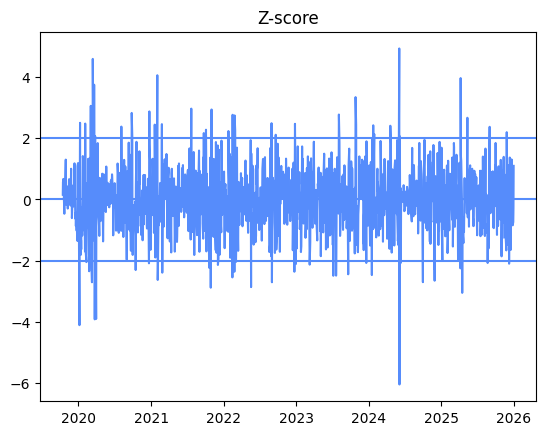

In [91]:
z = (residual - residual.rolling(50).mean()) / residual.rolling(50).std()
import matplotlib.pyplot as plt

plt.figure()
plt.plot(z)
plt.axhline(2)
plt.axhline(-2)
plt.axhline(0)
plt.title("Z-score")
plt.show()

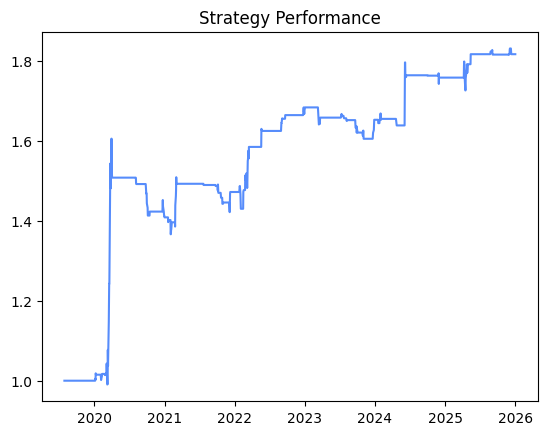

In [92]:
long = z < -2
short = z > 2
exit = abs(z) < 0.5
position = 0
positions = []

for i in range(len(z)):
    if z.iloc[i] < -2:
        position = 1
    elif z.iloc[i] > 2:
        position = -1
    elif abs(z.iloc[i]) < 0.5:
        position = 0

    positions.append(position)

positions = pd.Series(positions, index=z.index)

returns = df.loc[positions.index, 'returns']
strategy_returns = positions.shift(1) * returns
cum_returns = (1 + strategy_returns).cumprod()

plt.figure()
plt.plot(cum_returns)
plt.title("Strategy Performance")
plt.show()

In [93]:
print("Total Return:", cum_returns.iloc[-1])
print("Sharpe:", strategy_returns.mean() / strategy_returns.std())
print("Max Drawdown:", (cum_returns / cum_returns.cummax() - 1).min())

Total Return: 1.8172254709954532
Sharpe: 0.058118214049285966
Max Drawdown: -0.1490290613063745
